### In this file, we will learn about SimpleImputer, how to use it and parameters we can use this class to impute the missing values

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

- We will work on some specific columns of Titanic Data

In [75]:
# Import the dataset

df = pd.read_csv('titanic_toy.csv')

print(df.head())

    Age     Fare  Family  Survived
0  22.0   7.2500       1         0
1  38.0  71.2833       1         1
2  26.0   7.9250       0         1
3  35.0  53.1000       1         1
4  35.0   8.0500       0         0


In [76]:
# Let us check the Null percentage in each columns
print(df.isnull().mean()*100)

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64


In [77]:
X = df.iloc[:,:-1] # removing Survived column from Feature dataframe
y = df.iloc[:,-1] # Making a Series of Survived Data

### Filling the Nulls of Age and Fare column using SimpleImputer

In [78]:
from sklearn.impute import SimpleImputer

mean_impute = SimpleImputer(strategy = 'mean')
median_impute = SimpleImputer(strategy = 'median')

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=0)

In [80]:
print(f"Shape X_train -> {X_train.shape}")
print(f"Shape X_test -> {X_test.shape}")
print(f"Shape y_train -> {y_train.shape}")
print(f"Shape y_test -> {y_test.shape}")

Shape X_train -> (712, 3)
Shape X_test -> (179, 3)
Shape y_train -> (712,)
Shape y_test -> (179,)


In [81]:
from sklearn.compose import ColumnTransformer

# Imputing Mean Values
preprocessor1 = ColumnTransformer(transformers=[
    ('mean_impute' , mean_impute , ['Age','Fare'])
])

# Imputing with Median Values
preprocessor2 = ColumnTransformer(transformers=[
    ('median_impute' , median_impute , ['Age','Fare'])
])

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV


pipe1 = Pipeline(steps=[
    ('preprocess' , preprocessor1),
    ('logReg' , LogisticRegressionCV(cv= 10 , scoring='accuracy',random_state=0))
])

pipe2 = Pipeline(steps=[
    ('preprocess' , preprocessor2),
    ('logReg' , LogisticRegressionCV(cv= 10 , scoring='accuracy',random_state=0))
])

pipe1.fit(X_train,y_train)
pipe2.fit(X_train,y_train)

y_pred_mean = pipe1.predict(X_test)
y_pred_median = pipe2.predict(X_test)

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\

- We made two Models (i) Imputing Mean values to the Features and then training it and predicting the values
- (ii) Imputing Median Values to the Features and then training it and predicting the values

In [82]:
from sklearn.metrics import accuracy_score
print(f"Accuracy Score Mean Impute -> {accuracy_score(y_test , y_pred_mean)}")
print(f"Accuracy Score Median Impute -> {accuracy_score(y_test , y_pred_median)}")

Accuracy Score Mean Impute -> 0.6871508379888268
Accuracy Score Median Impute -> 0.6871508379888268


140     NaN
439    31.0
817    31.0
378    20.0
491    21.0
       ... 
835    39.0
192    19.0
629     NaN
559    36.0
684    60.0
Name: Age, Length: 712, dtype: float64

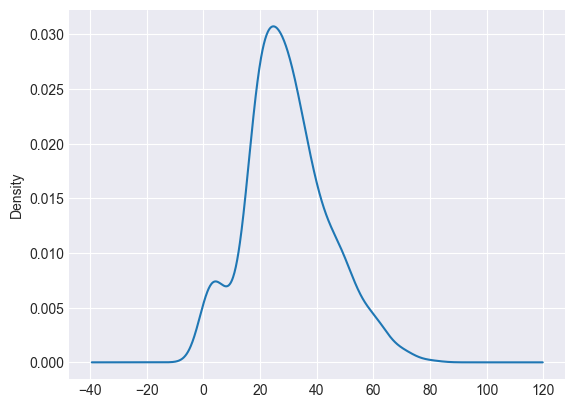

In [83]:
# Let us check the Distribution b/w original column and Imputed Column
X['Age'].plot.density()
X_train['Age']

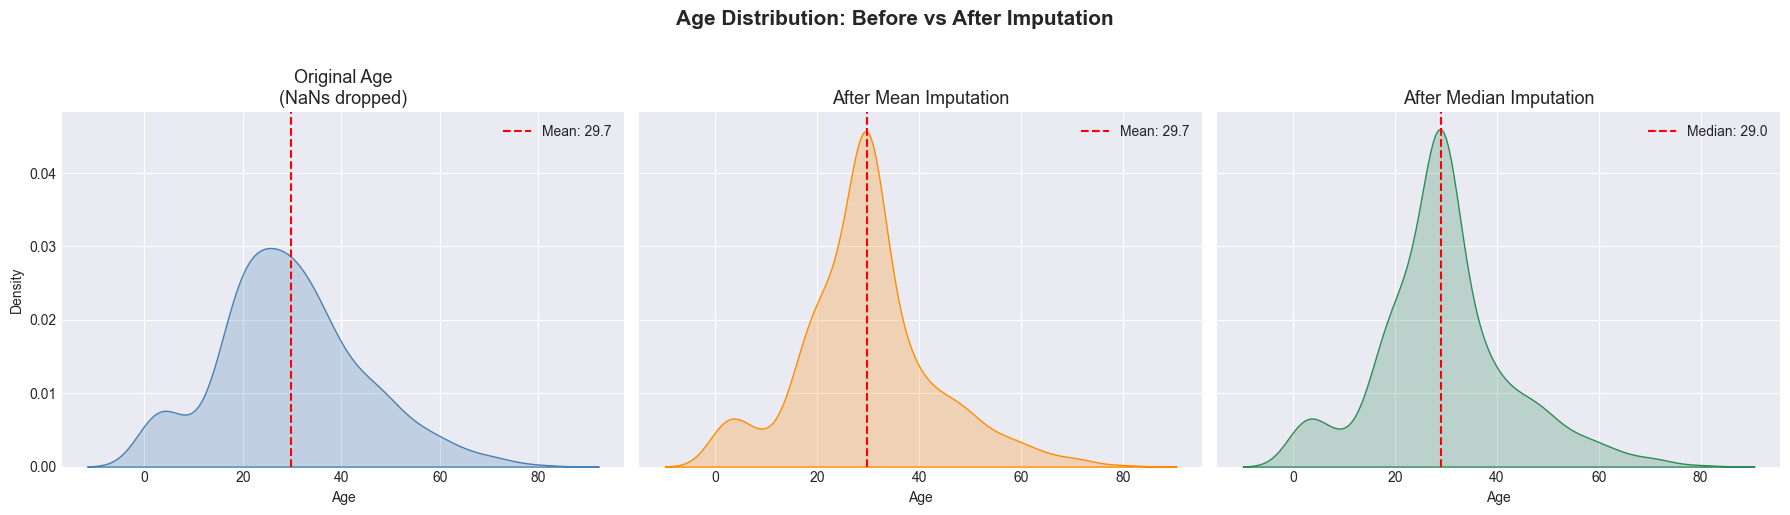

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Original Age (with NaNs dropped for plotting) ──────────────────────────
age_original = X_train['Age'].dropna()

# ── 2. Get Mean-imputed Age ───────────────────────────────────────────────────
# fit on train, transform train (same logic as inside pipe1)
age_mean_imputed = mean_impute.fit_transform(X_train[['Age']])  # returns 2D array
age_mean_imputed = age_mean_imputed.flatten()                   # make 1D for plotting

# ── 3. Get Median-imputed Age ─────────────────────────────────────────────────
age_median_imputed = median_impute.fit_transform(X_train[['Age']])
age_median_imputed = age_median_imputed.flatten()

# ── 4. Plot all 3 KDEs ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.kdeplot(age_original,        ax=axes[0], fill=True, color='steelblue')
axes[0].set_title('Original Age\n(NaNs dropped)', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].axvline(age_original.mean(), color='red', linestyle='--', label=f'Mean: {age_original.mean():.1f}')
axes[0].legend()

sns.kdeplot(age_mean_imputed,    ax=axes[1], fill=True, color='darkorange')
axes[1].set_title('After Mean Imputation', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].axvline(age_mean_imputed.mean(), color='red', linestyle='--', label=f'Mean: {age_mean_imputed.mean():.1f}')
axes[1].legend()

sns.kdeplot(age_median_imputed,  ax=axes[2], fill=True, color='seagreen')
axes[2].set_title('After Median Imputation', fontsize=13)
axes[2].set_xlabel('Age')
axes[2].axvline(np.median(age_median_imputed), color='red', linestyle='--', label=f'Median: {np.median(age_median_imputed):.1f}')
axes[2].legend()

plt.suptitle('Age Distribution: Before vs After Imputation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### ***Large difference in the distribution In the Age column -> Thus we cannot apply Imputaion here***

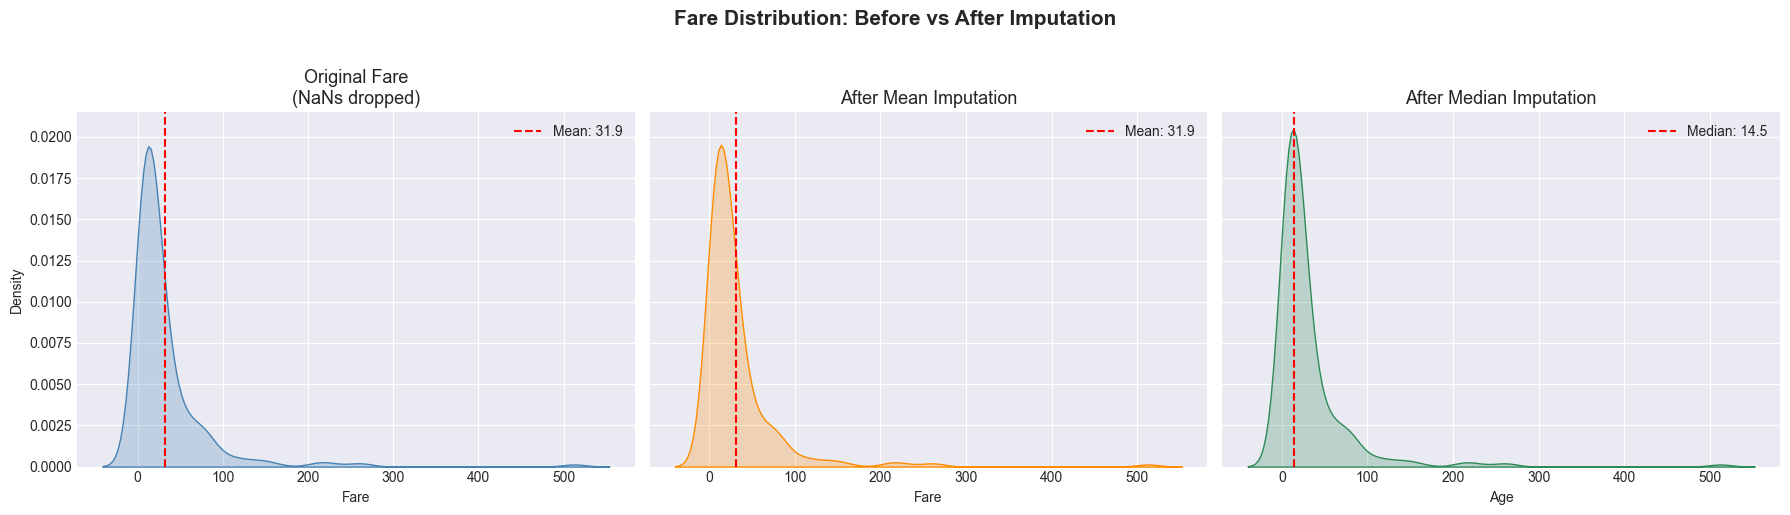

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Original Age (with NaNs dropped for plotting) ──────────────────────────
fare_original = X_train['Fare'].dropna()

# ── 2. Get Mean-imputed Fare ───────────────────────────────────────────────────
# fit on train, transform train (same logic as inside pipe1)
fare_mean_imputed = mean_impute.fit_transform(X_train[['Fare']])  # returns 2D array
fare_mean_imputed = fare_mean_imputed.flatten()                   # make 1D for plotting

# ── 3. Get Median-imputed Fare ─────────────────────────────────────────────────
fare_median_imputed = median_impute.fit_transform(X_train[['Fare']])
fare_median_imputed = fare_median_imputed.flatten()

# ── 4. Plot all 3 KDEs ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.kdeplot(fare_original,        ax=axes[0], fill=True, color='steelblue')
axes[0].set_title('Original Fare\n(NaNs dropped)', fontsize=13)
axes[0].set_xlabel('Fare')
axes[0].axvline(fare_original.mean(), color='red', linestyle='--', label=f'Mean: {fare_original.mean():.1f}')
axes[0].legend()

sns.kdeplot(fare_mean_imputed,    ax=axes[1], fill=True, color='darkorange')
axes[1].set_title('After Mean Imputation', fontsize=13)
axes[1].set_xlabel('Fare')
axes[1].axvline(fare_mean_imputed.mean(), color='red', linestyle='--', label=f'Mean: {fare_mean_imputed.mean():.1f}')
axes[1].legend()

sns.kdeplot(fare_median_imputed,  ax=axes[2], fill=True, color='seagreen')
axes[2].set_title('After Median Imputation', fontsize=13)
axes[2].set_xlabel('Age')
axes[2].axvline(np.median(fare_median_imputed), color='red', linestyle='--', label=f'Median: {np.median(fare_median_imputed):.1f}')
axes[2].legend()

plt.suptitle('Fare Distribution: Before vs After Imputation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### ***No difference in the distribution In the fare column -> Thus we can apply Imputaion here***

### Let us check to fit the model without any nan values by just dropping them

In [86]:
new_df = df.dropna()

X = new_df.iloc[:,:-1]
y = new_df.iloc[:,-1]

In [87]:
X_train_dropped,X_test_dropped,y_train_dropped,y_test_dropped = train_test_split(X,y , test_size=.2 , random_state=41)

In [88]:
print(f'X_train -> {X_train.shape}')
print(f'X_test -> {X_train.shape}')

print(f'X_train -> {X_train_dropped.shape}')
print(f'X_test -> {X_train_dropped.shape}')



X_train -> (712, 3)
X_test -> (712, 3)
X_train -> (540, 3)
X_test -> (540, 3)


In [89]:
print(f"X_train -> {X_train_dropped.isnull().mean()*100}")
print(f"X_test -> {X_test_dropped.isnull().mean()*100}")

X_train -> Age       0.0
Fare      0.0
Family    0.0
dtype: float64
X_test -> Age       0.0
Fare      0.0
Family    0.0
dtype: float64


In [90]:
from sklearn.linear_model import LogisticRegressionCV
lr = LogisticRegressionCV(cv = 5 , scoring='accuracy')
lr.fit(X_train_dropped,y_train_dropped)

y_pred_dropped = lr.predict(X_test_dropped)

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


In [93]:
# Comparing the Accuracy Scores
print(f"Accuracy Score Dropped-> {accuracy_score(y_test_dropped , y_pred_dropped)}")
print(f"Accuracy Score Mean-> {accuracy_score(y_test , y_pred_mean)}")
print(f"Accuracy Score Median-> {accuracy_score(y_test , y_pred_median)}")

Accuracy Score Dropped-> 0.6814814814814815
Accuracy Score Mean-> 0.6871508379888268
Accuracy Score Median-> 0.6871508379888268


### ***Conclusion***

- Learned simple_imputer and the advantages and disadvantages of it. 
- Did a small case study where I used complete production ready pipeline to impute the columns and fit the Logistic Regression model with 5 fold cv on it. 

- Checked the Accuracy score after both mean imputation and median imputation. Both were almost same 68%. 

- Also checked the difference in the distribution before and after imputaion.

### ***Using Simple Imputer To Impute Categorical columns***

In [128]:
# Importing the Data
df = pd.read_csv('sale-price.csv' , usecols=['GarageQual','FireplaceQu','SalePrice'])

df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   FireplaceQu  770 non-null    str  
 1   GarageQual   1379 non-null   str  
 2   SalePrice    1460 non-null   int64
dtypes: int64(1), str(2)
memory usage: 38.9 KB


In [130]:
print(df.isnull().mean()*100)

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64


- 47.26 % data of FireplaceQu Feature is Null
- Around 5.54% of GarageQual Feature is Null
- Target Column has No Nulls

In [131]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Firstly we will work on Categorical Column

In [133]:
for col in X.columns:
    print(df[col].value_counts())
    print()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64



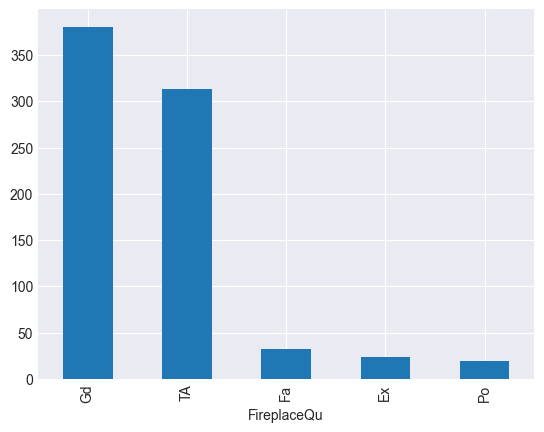

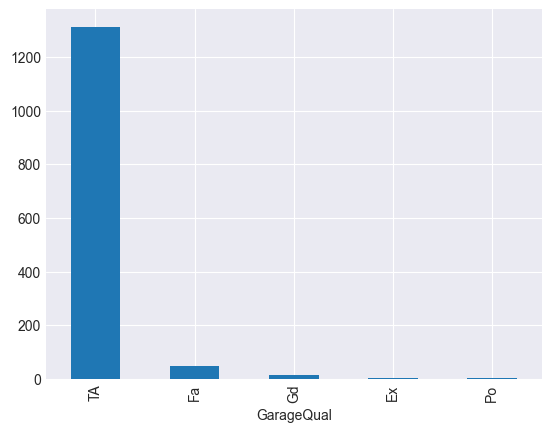

In [143]:
for col in X.columns:
    plt.subplot(111)
    X[col].value_counts().plot(kind='bar')
    plt.show()

- **Clealy Imputing the FireplaceQu with most frequent value will be the bad choice -> since two of the most frequent values are almost same**
- **Imputing GarageQual is a good Idea with Most frequent value -> but let's check the distribution also after Imputing**

In [144]:
X['FireplaceQu_imp'] = X['FireplaceQu'].fillna('Gd')
X['GarageQual_imp'] = X['GarageQual'].fillna('TA')

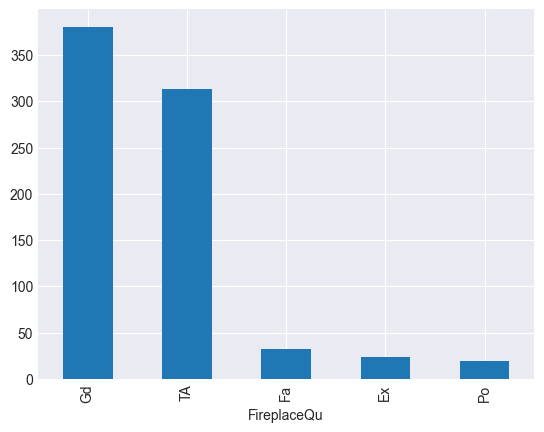

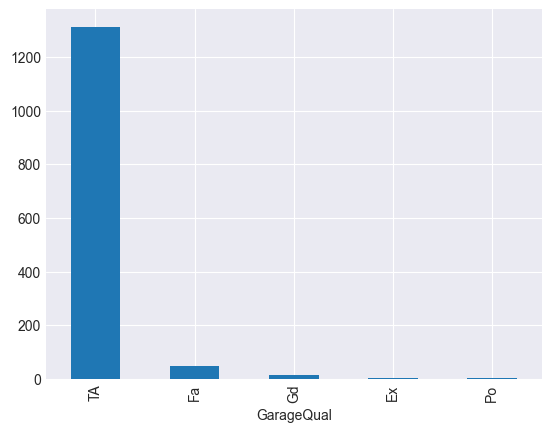

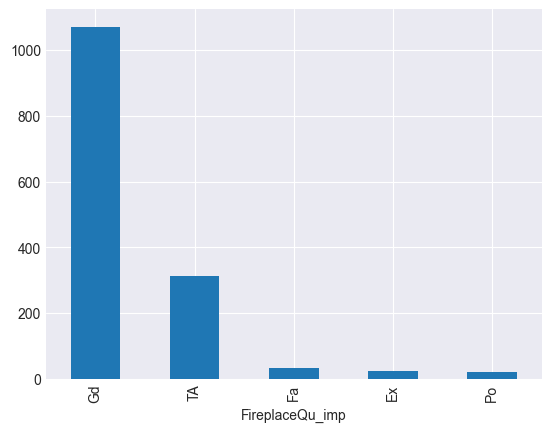

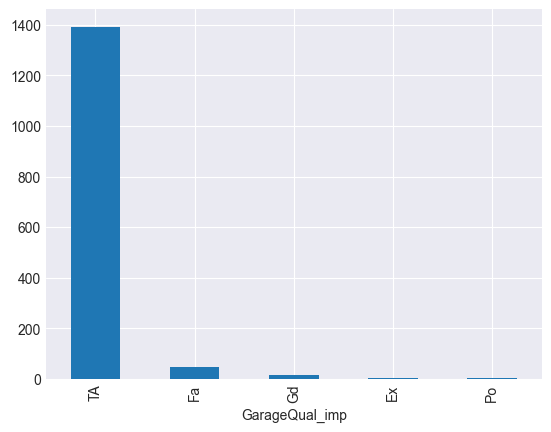

In [145]:
for col in X.columns:
    plt.subplot(111)
    X[col].value_counts().plot(kind='bar')
    plt.show()

### Check the Distribution of the Categories of each Feature Wrt Sale_price

In [146]:
df = pd.concat([X,y],axis=1)

<Axes: ylabel='Density'>

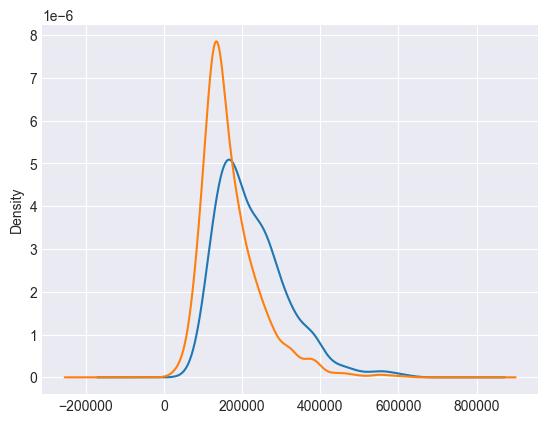

In [148]:
df['SalePrice'][df['FireplaceQu']=='Gd'].plot(kind='kde')
df['SalePrice'][df['FireplaceQu_imp']=='Gd'].plot(kind='kde')


- Clearly the distribution changed after Imputation which is a bad sign

<Axes: ylabel='Density'>

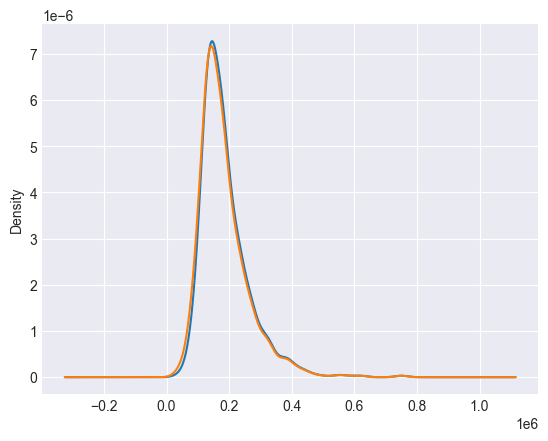

In [149]:
df['SalePrice'][df['GarageQual']=='TA'].plot(kind='kde')
df['SalePrice'][df['GarageQual_imp']=='TA'].plot(kind='kde')


- See this is completely overlapped -> Showing that we can impute this Feature with most_frequent value

### Using Sklearn To Impute and then Model Fitting
- This dataset is Ames Housing DataSet and if Nan values in categories means that house doesn't have fireplace or garage
- Thus instead of filling nan values with most frequent, the appropriate thing is to create category called "None" and use OrdinalEncoding

In [158]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   FireplaceQu      770 non-null    str  
 1   GarageQual       1379 non-null   str  
 2   FireplaceQu_imp  1460 non-null   str  
 3   GarageQual_imp   1460 non-null   str  
 4   SalePrice        1460 non-null   int64
dtypes: int64(1), str(4)
memory usage: 67.4 KB


In [153]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

print(f'X_train -> {X_train.shape}')
print(f'X_test-> {X_test.shape}')
print(f'y_train -> {y_train.shape}')
print(f'y_test-> {y_test.shape}')


X_train -> (1168, 2)
X_test-> (292, 2)
y_train -> (1168,)
y_test-> (292,)


In [155]:
X['FireplaceQu'].unique()

<ArrowStringArray>
[nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po']
Length: 6, dtype: str

In [156]:
X_train.columns.to_list()

['FireplaceQu', 'GarageQual']

In [163]:
# Simple Impute with most frequent value

categories = [['None','Po','Fa','TA','Gd','Ex'], # We created 2D list since we are Encoding Two columns inside OrdinalEncoder (VIP Step!!)
              ['None','Po','Fa','TA','Gd','Ex']]  

impute = SimpleImputer(strategy='constant' , fill_value='None')
ord_enc = OrdinalEncoder(categories=categories , dtype=np.int32 , handle_unknown='use_encoded_value' , unknown_value=-1)

cols = X_train.columns.to_list()


sub_pipeline = Pipeline(steps=[
    ('impute' , impute),
    ('encode',ord_enc)
])

preprocess = ColumnTransformer(transformers=[
    ('ordinal' , sub_pipeline , cols)
])


lr = LinearRegression()

final_pipe = Pipeline(steps=[
    ('preprocess'  , preprocess),
    ('model' , lr)
])

final_pipe.set_output(transform='pandas')

final_pipe.fit(X_train,y_train)

y_pred = final_pipe.predict(X_test)

from sklearn.metrics import r2_score
print(f'R2 score -> {r2_score(y_test , y_pred)}')



R2 score -> 0.29763740829890706


In [ ]:
from sklearn import set_config

set_config(display='diagram')


In [165]:
final_pipe.named_steps

{'preprocess': ColumnTransformer(transformers=[('ordinal',
                                  Pipeline(steps=[('impute',
                                                   SimpleImputer(fill_value='None',
                                                                 strategy='constant')),
                                                  ('encode',
                                                   OrdinalEncoder(categories=[['None',
                                                                               'Po',
                                                                               'Fa',
                                                                               'TA',
                                                                               'Gd',
                                                                               'Ex'],
                                                                              ['None',
                                               

In [ ]:
final_pipe.named_steps['preprocess'][]

KeyError: "'0' is not a valid transformer name"

In [166]:
from sklearn import set_config

set_config(display='diagram')
final_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars